In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz
from IPython.core.pylabtools import figsize

from my_work.my_ch01 import sigma



WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
az. style.use('arviz-grayscale')
from cycler import cycler
default_cycler = cycler(color=['#000000', '#6a6a6a', '#bebebe', '#2a2eec'])
plt.rc('axes', prop_cycle=default_cycler)
plt.rc('figure', dpi=300)

In [3]:
np.random.seed(123)
trials = 4
theta_real = 0.35 # unknown value in a real experiment
data = pz.Binomial(n=1, p=theta_real).rvs(trials)
data

array([0, 0, 0, 0], dtype=int64)

In [4]:
with pm.Model() as our_first_model:
    theta = pm.Beta('theta', alpha=1.0, beta=1.0)
    y = pm.Bernoulli('y', p=theta,observed=data)
    idata = pm.sample(draws=1000, chains=4, tune=1000, random_seed=4591)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.


<function matplotlib.pyplot.savefig(*args, **kwargs) -> 'None'>

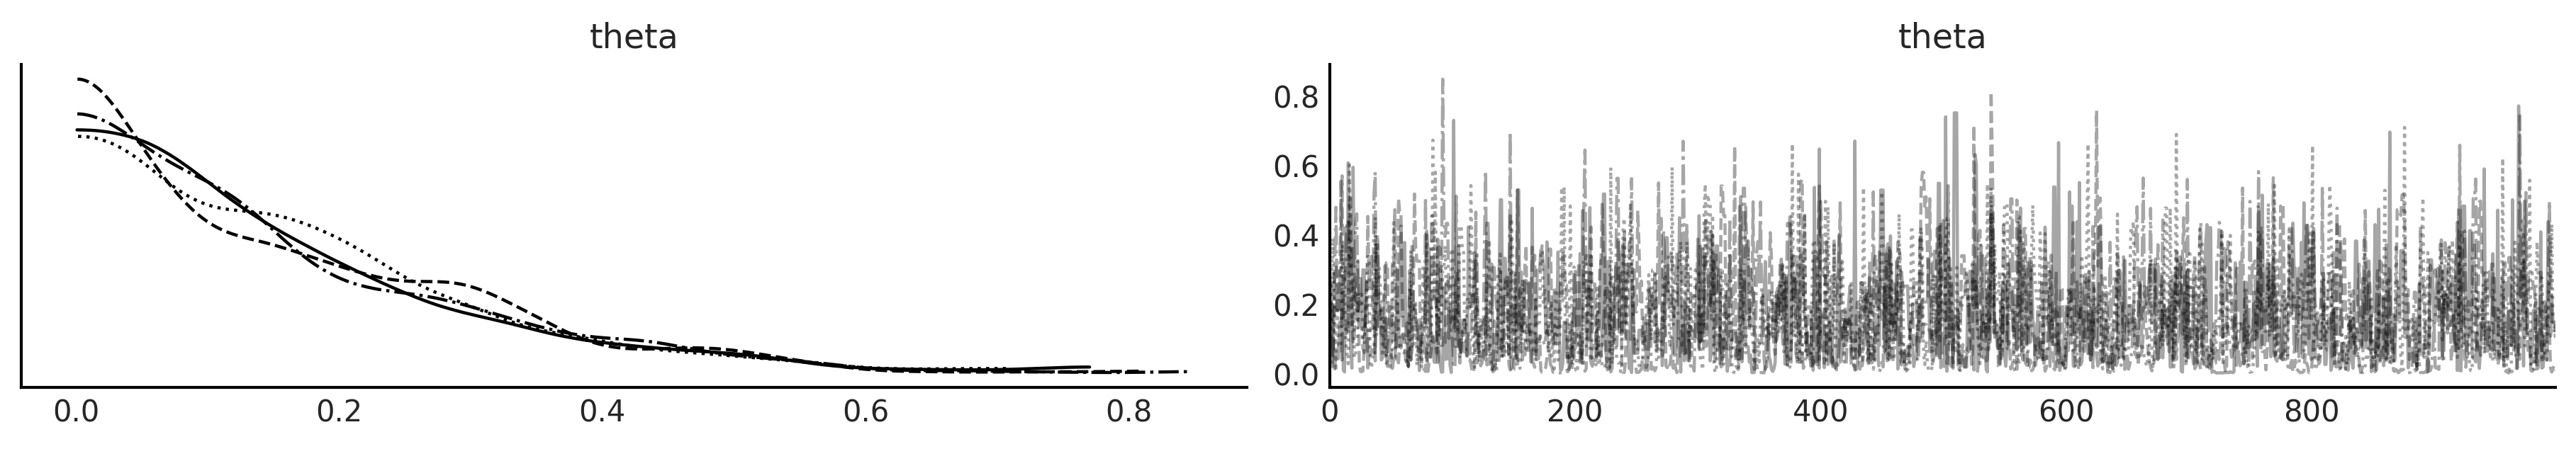

In [5]:
az.plot_trace(idata)
plt.savefig

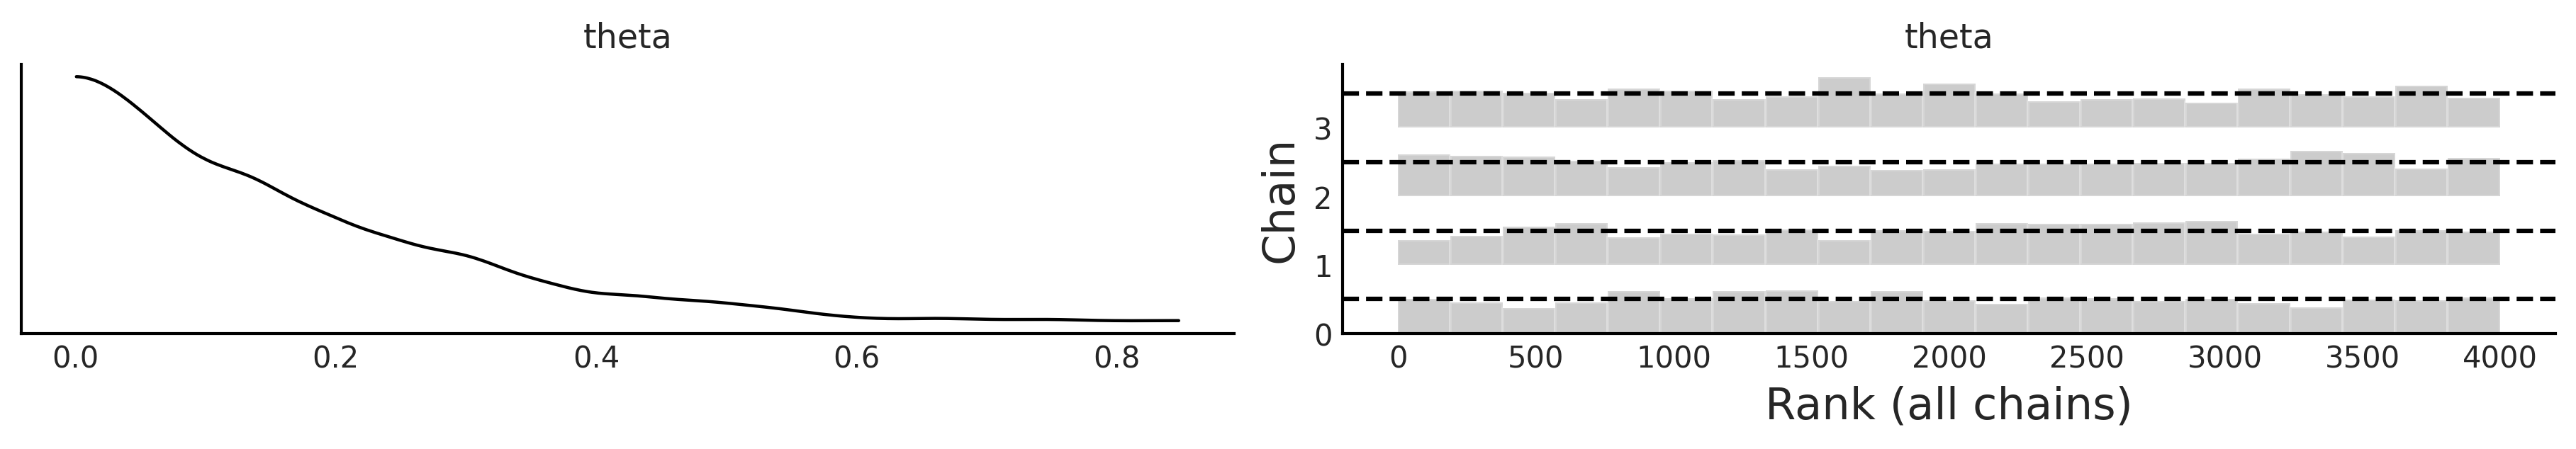

In [6]:
az.plot_trace(idata, kind='rank_bars', combined=True, rank_kwargs={'colors': 'k'})
plt.savefig('fig/idata_rank.png')

In [7]:
az.summary(idata, kind='stats').round(2)

,mean,sd,hdi_3%,hdi_97%
theta,0.16,0.14,0.0,0.43


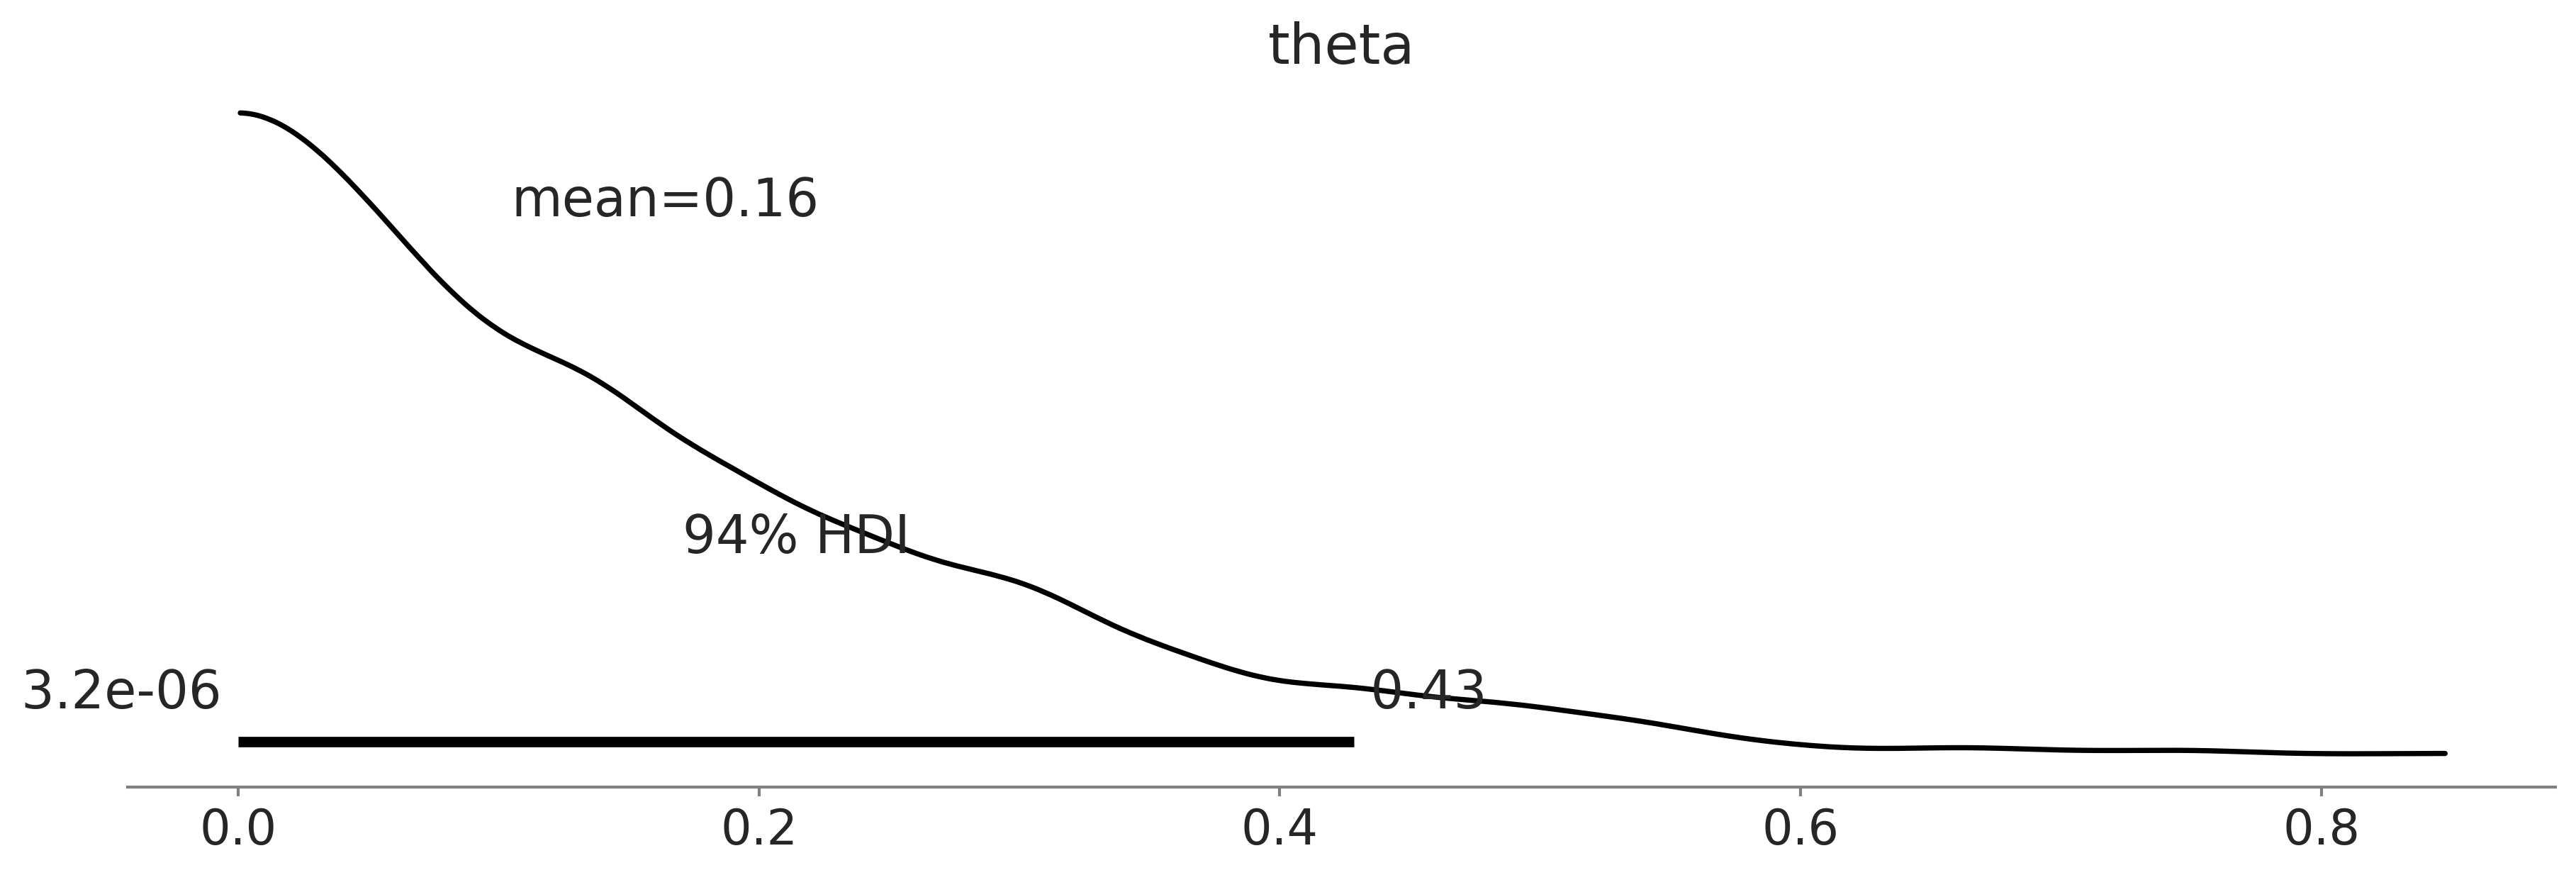

In [8]:
az.plot_posterior(idata, figsize=(12, 4))
plt.savefig('fig/idata_posterior.png')

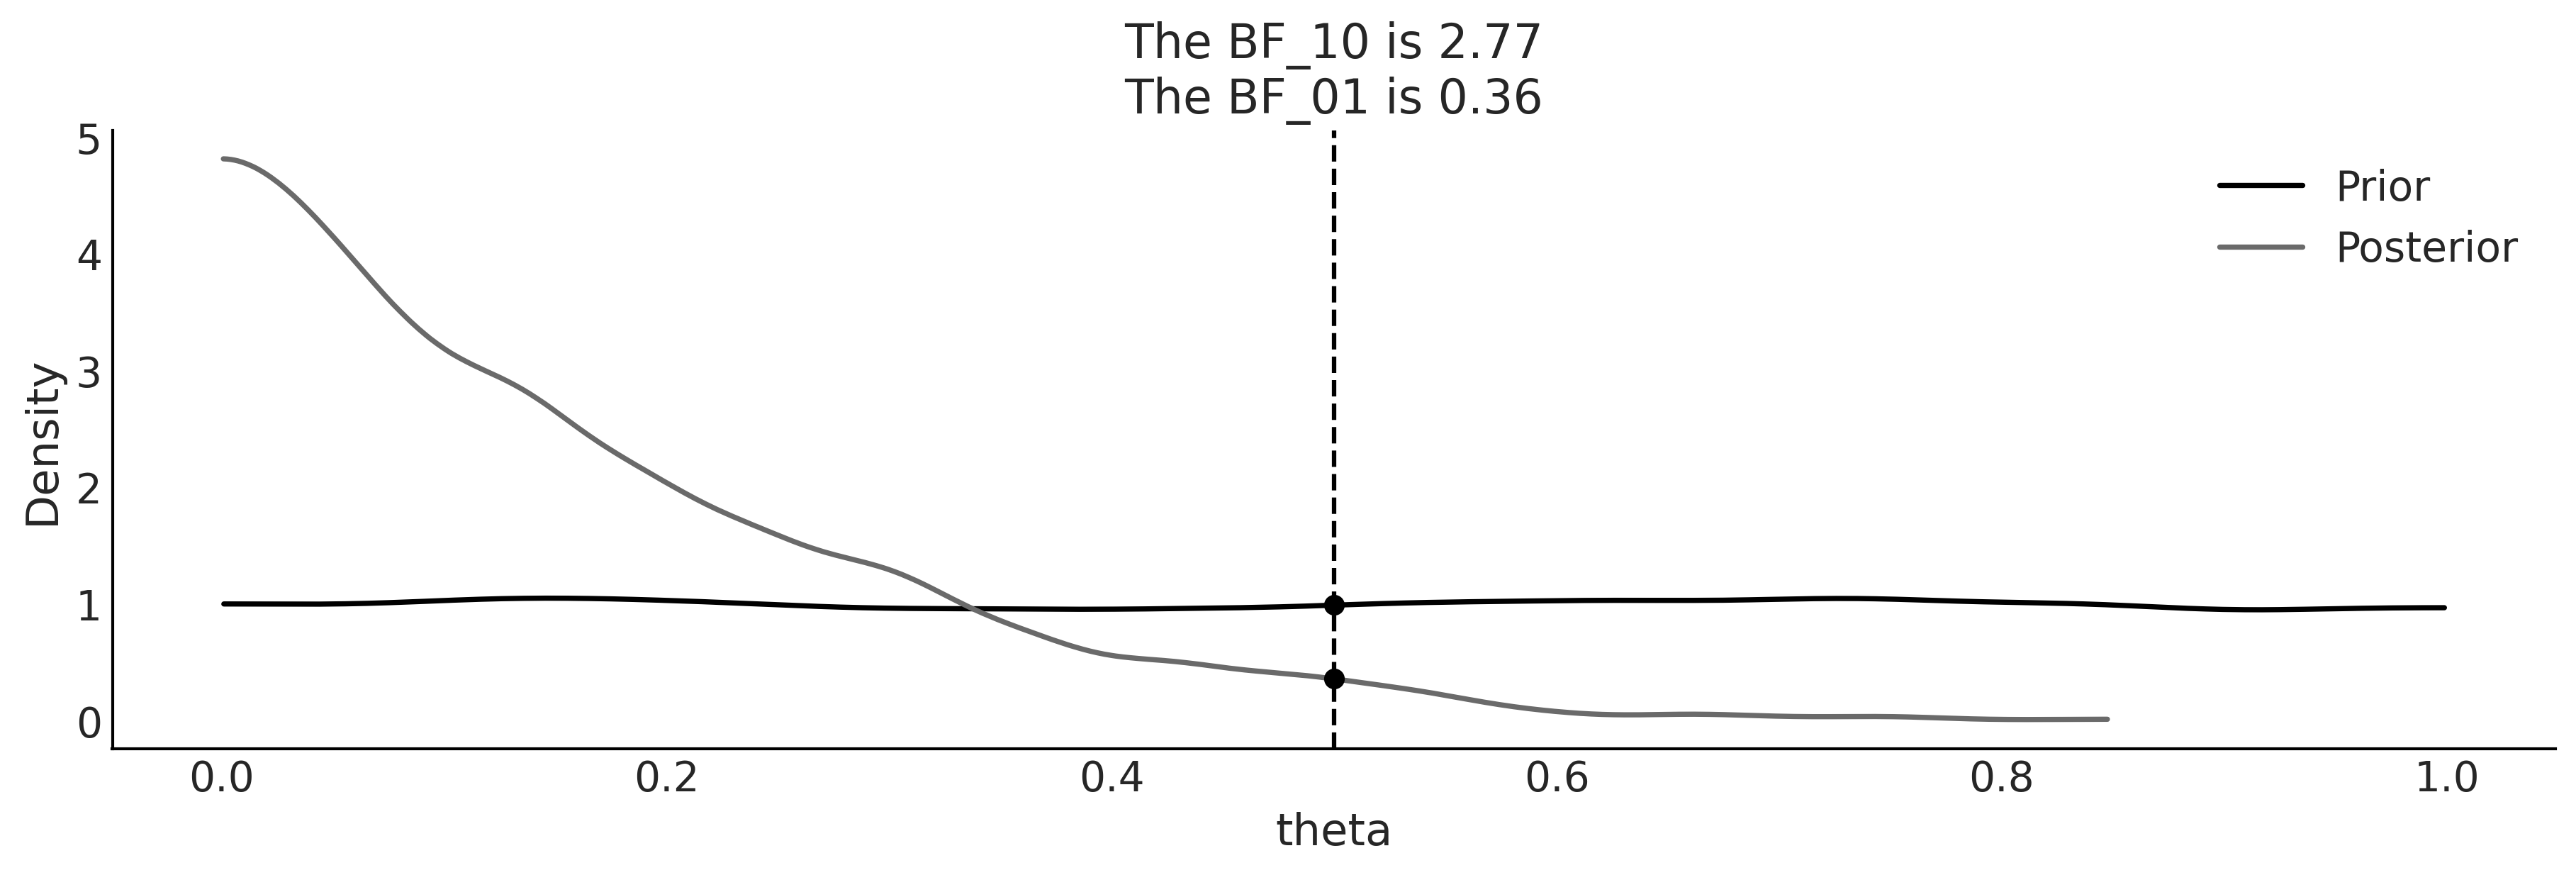

In [9]:
az.plot_bf(idata, var_name='theta', prior=np.random.uniform(0, 1, 10000), ref_val=0.5, figsize=(12, 4))
plt.savefig('fig/idata_bf.png')

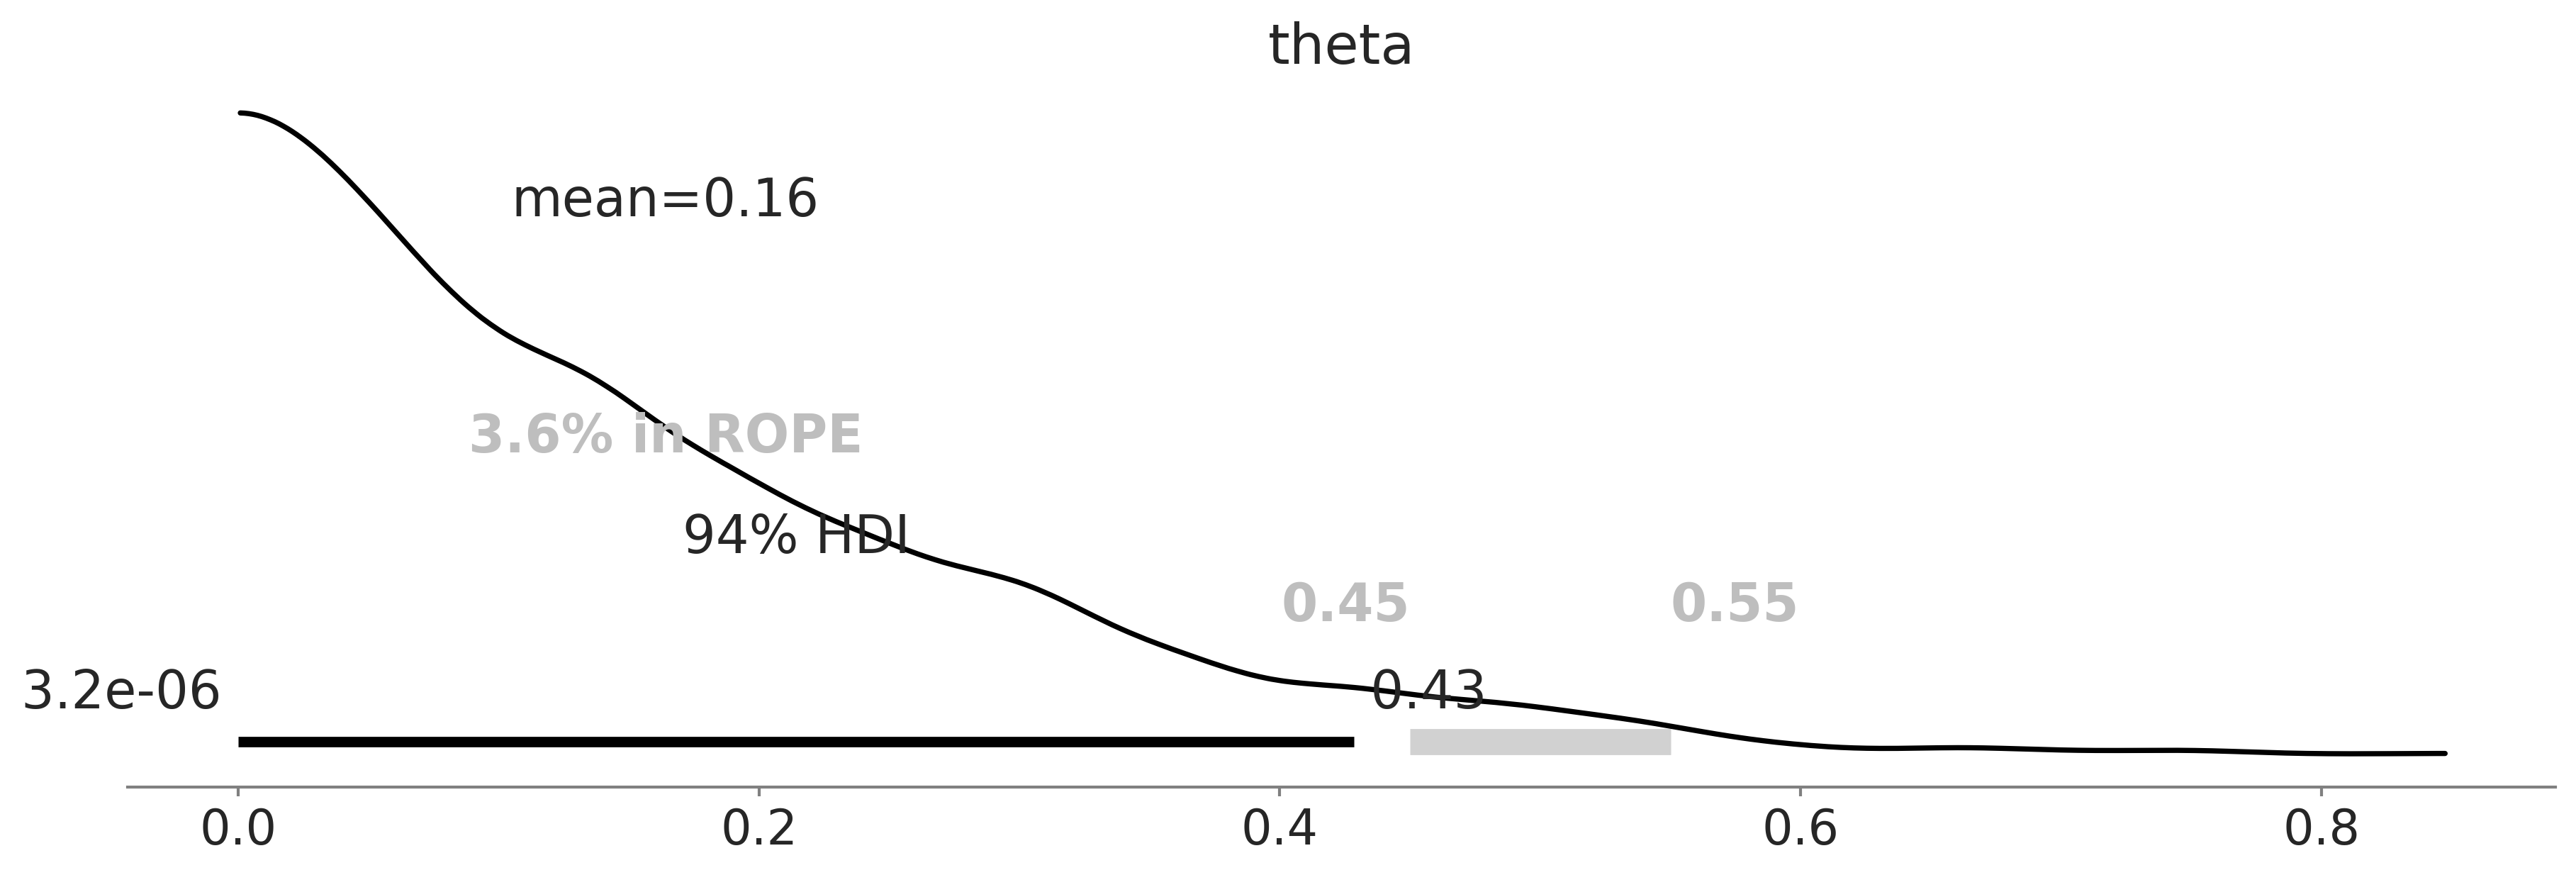

In [10]:
az.plot_posterior(idata, rope=[0.45, 0.55], figsize=(12, 4))
plt.savefig('fig/idata_posterior_rope.png')

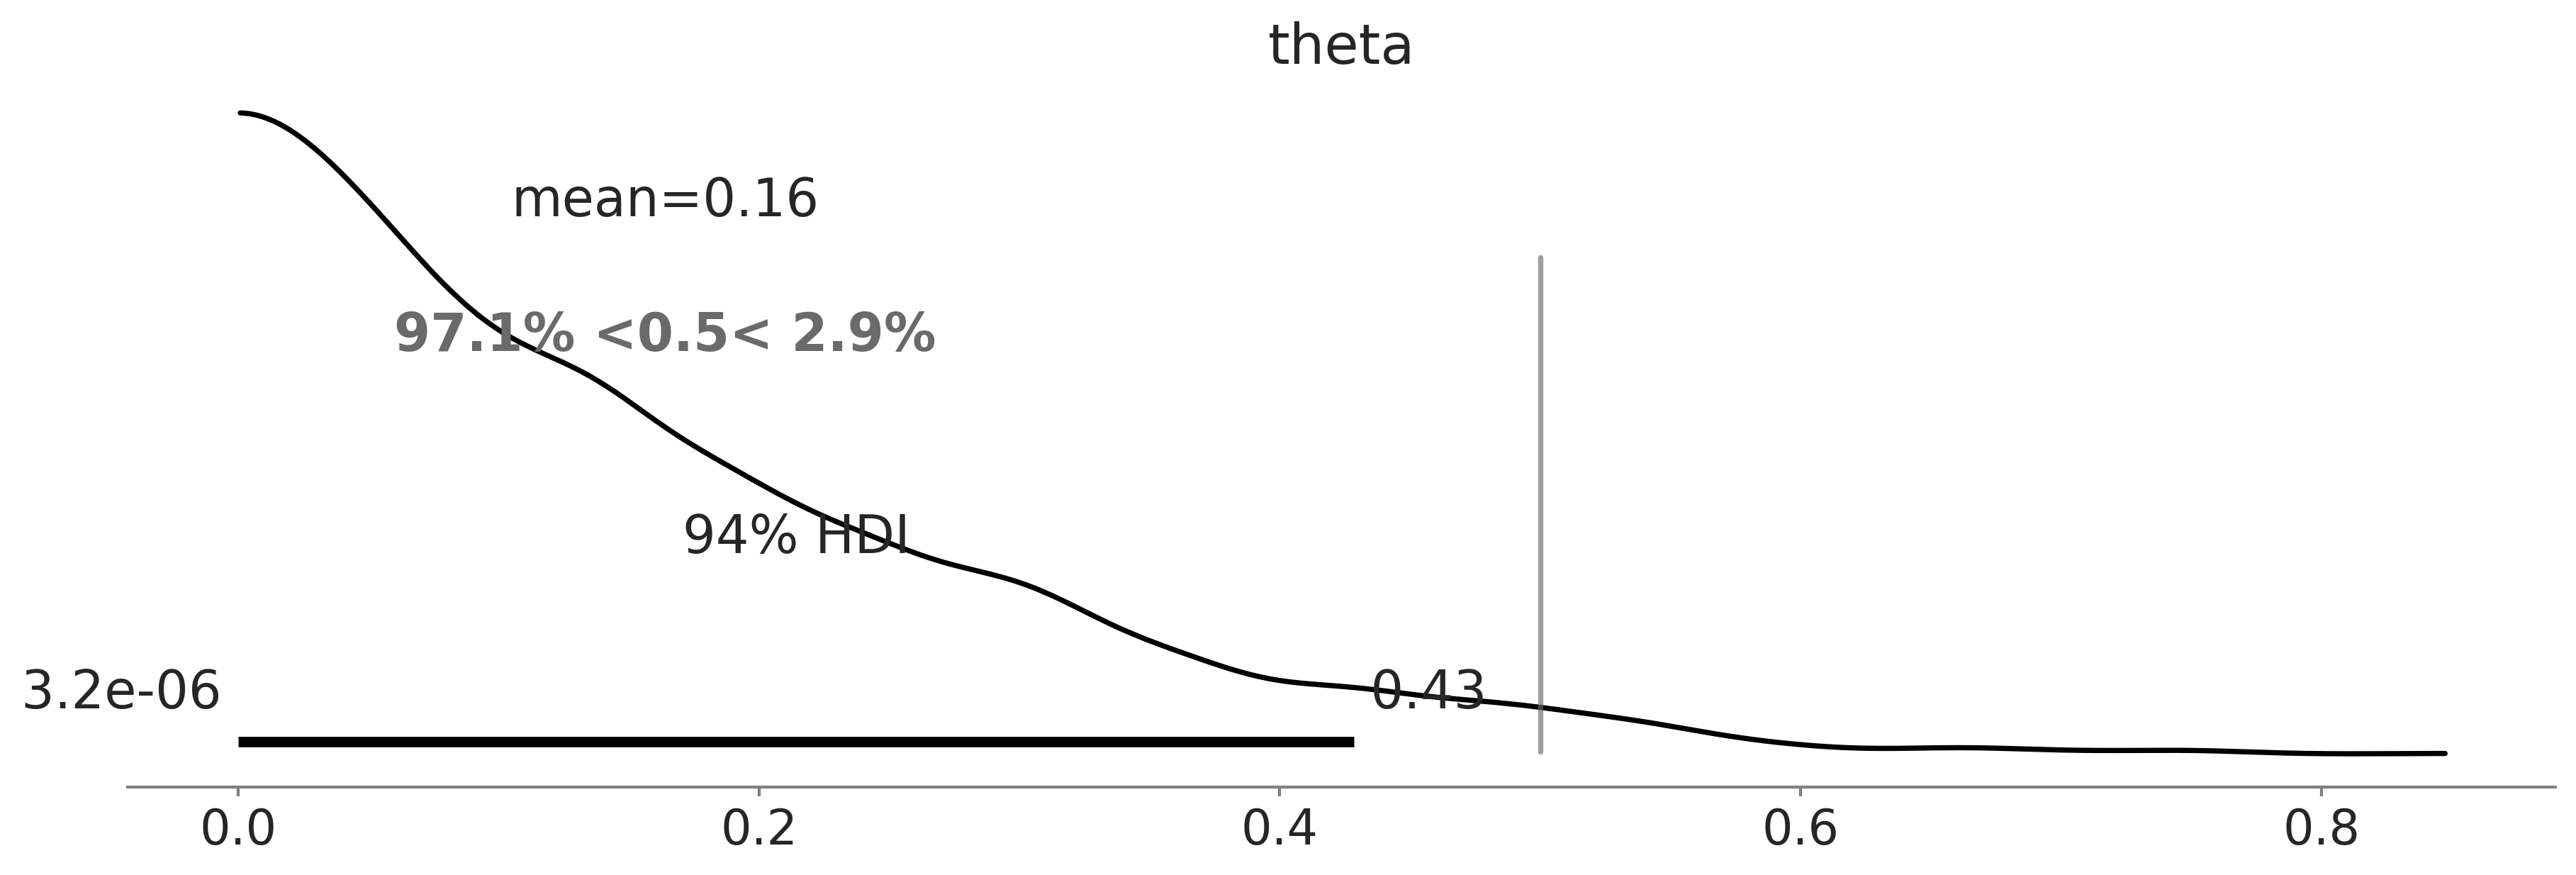

In [11]:
az.plot_posterior(idata, ref_val=0.5, figsize=(12, 4))
plt.savefig('fig/udata_posterior_ref.png')

In [12]:
grid = np.linspace(0, 1, 200)
theta_pos = idata.posterior['theta']
lossf_a = [np.mean(abs(i - theta_pos)) for i in grid]
lossf_b = [np.mean((i - theta_pos)**2) for i in grid]
np.argmin(lossf_a)

25

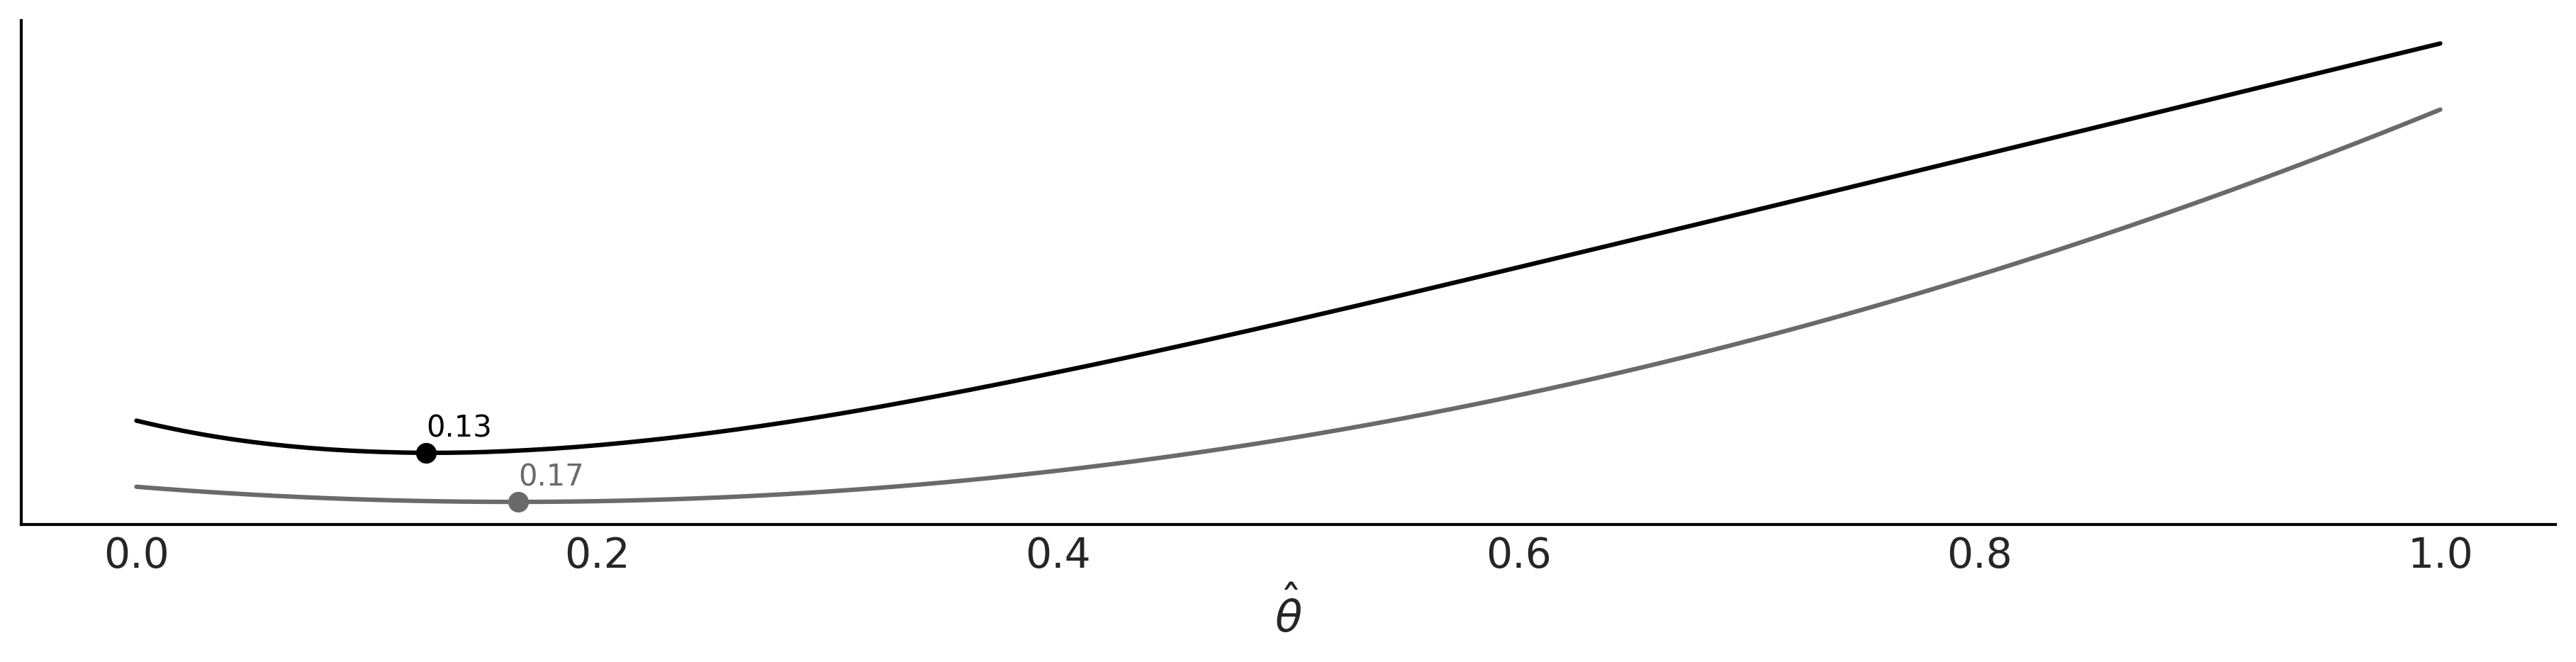

In [13]:
grid = np.linspace(0, 1, 200)
theta_pos = idata.posterior['theta']
lossf_a = [np.mean(abs(i - theta_pos)) for i in grid]
lossf_b = [np.mean((i - theta_pos)**2) for i in grid]

_, ax = plt.subplots(figsize=(12, 3))
for lossf, c in zip([lossf_a, lossf_b], ['C0', 'C1']):
    mini = np.argmin(lossf)
    ax.plot(grid, lossf, c)
    ax.plot(grid[mini], lossf[mini], 'o', color=c)
    ax.annotate('{:.2f}'.format(grid[mini]), (grid[mini], lossf[mini] + 0.03), color=c)
    ax.set_yticks([])
    ax.set_xlabel(r'$\hat \theta$')

plt.savefig('fig/idata_loss.png')

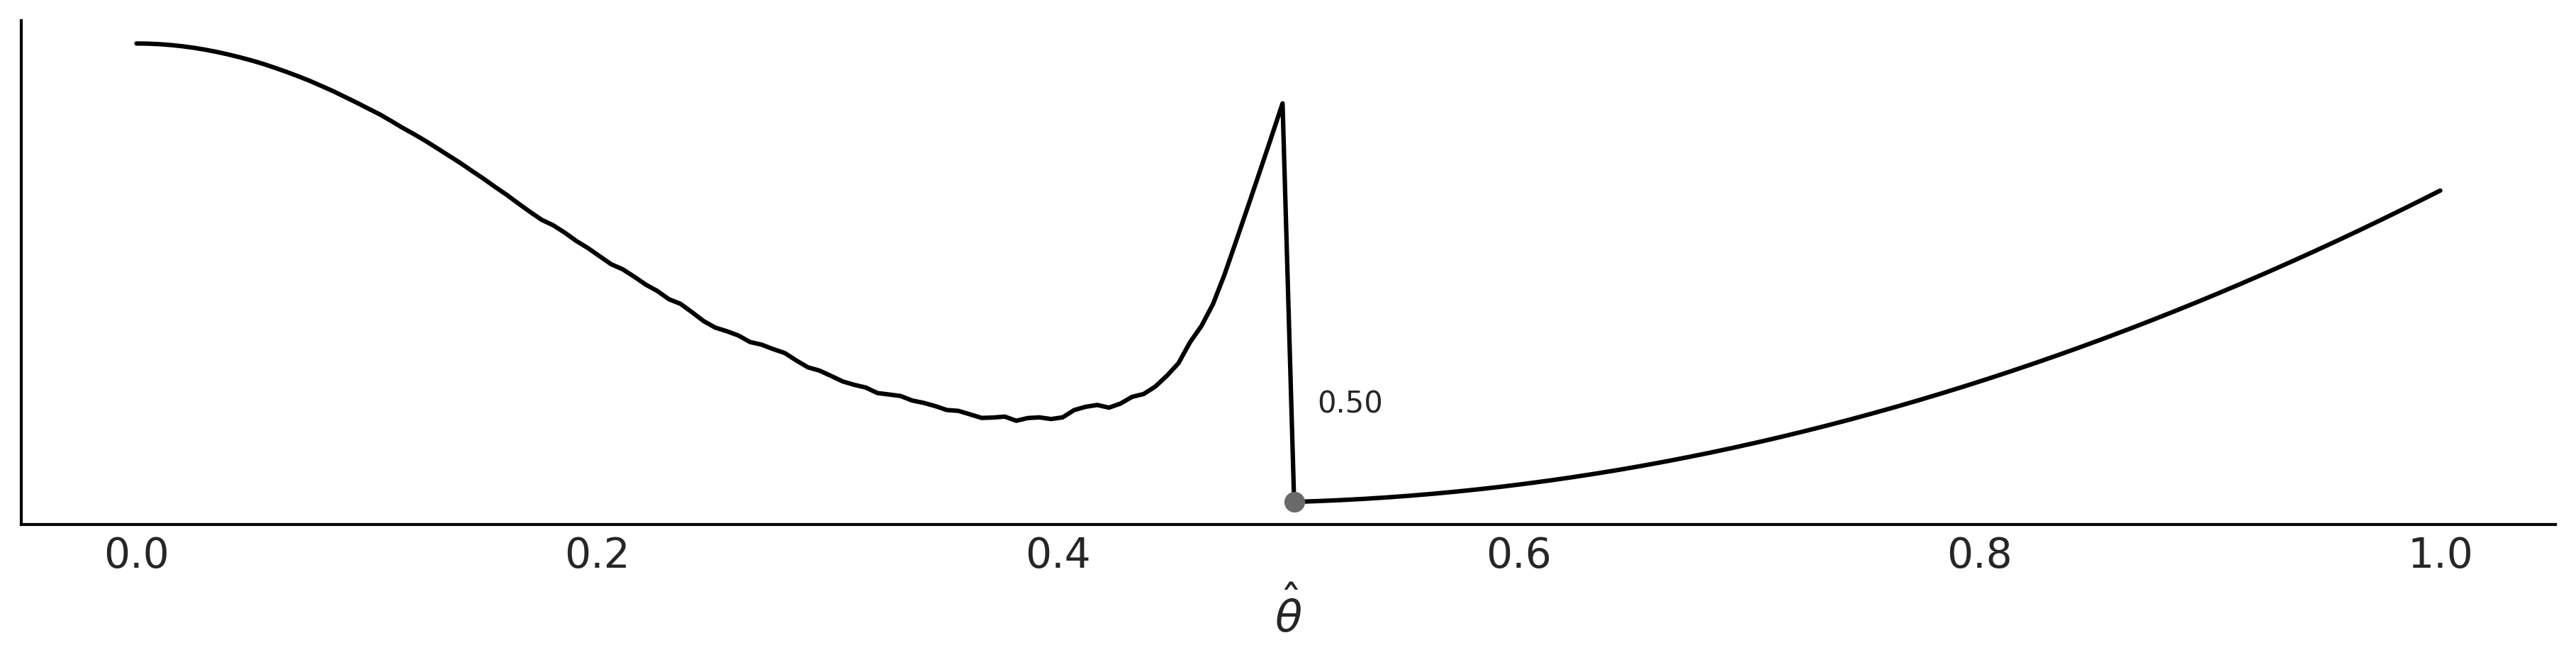

In [14]:
lossf = []
for i in grid:
    if i < 0.5:
        f = 1/np.median(theta_pos / np.abs(i**2 - theta_pos))
    else:
        f = np.mean((i - theta_pos)**2 + np.exp(-i)) - 0.25
    lossf.append(f)

mini = np.argmin(lossf)

_, ax = plt.subplots(figsize=(12, 3))
ax.plot(grid, lossf)
ax.plot(grid[mini], lossf[mini], 'o')
ax.annotate('{:.2f}'.format(grid[mini]), (grid[mini] +0.01, lossf[mini] + 0.1))
ax.set_yticks([])
ax.set_xlabel(r'$\hat \theta$')
plt.savefig('fig/idata_loss2.png')

Data: [51.06 55.12 53.73 50.24 52.05 56.4  48.45 52.34 55.65 51.49 51.86 63.43
 53.   56.09 51.93 52.31 52.33 57.48 57.44 55.14 53.93 54.62 56.09 68.58
 51.36 55.47 50.73 51.94 54.95 50.39 52.91 51.5  52.68 47.72 49.73 51.82
 54.99 52.84 53.19 54.52 51.46 53.73 51.61 49.81 52.42 54.3  53.84 53.16]



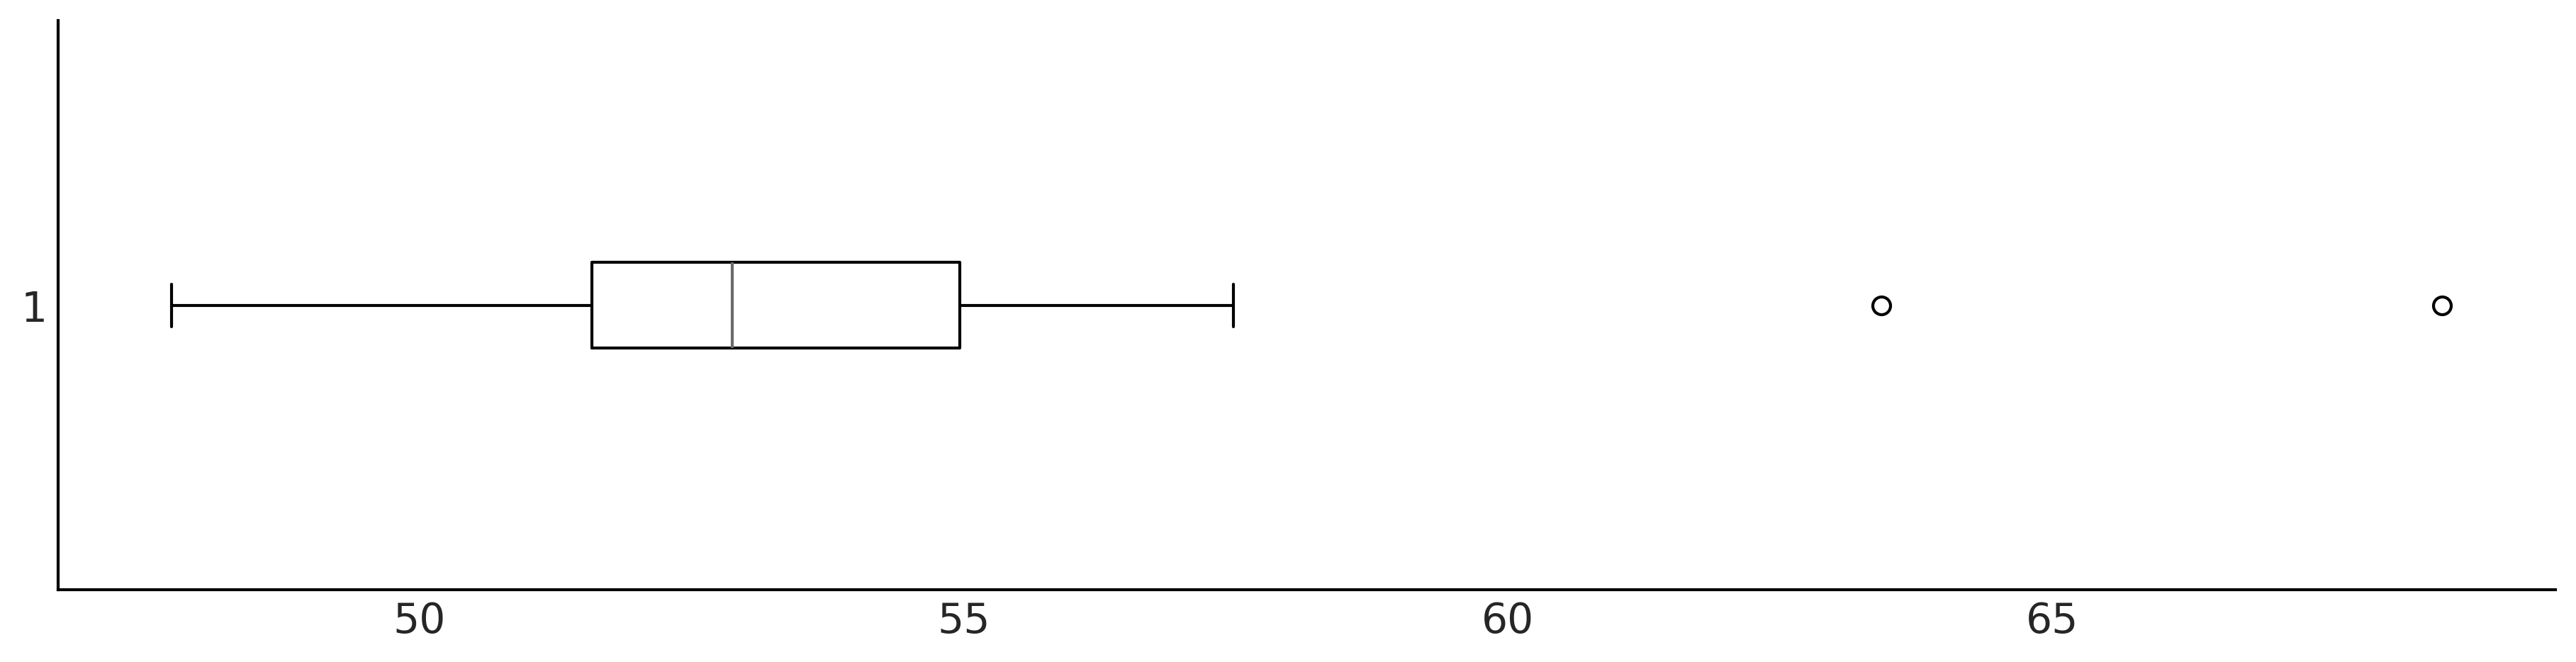

In [15]:
data = np.loadtxt('../code/data/chemical_shifts.csv')
print(f'Data: {data}')
print()

_,ax = plt.subplots(figsize=(12, 3))
ax.boxplot(data, vert=False)
plt.savefig('fig/boxplot.png')

In [16]:
with pm.Model() as model_g:
    µ = pm.Uniform('µ', lower=40, upper=70)
    σ = pm.HalfNormal('σ', sigma=5)
    𝛄 = pm.Normal('𝛄', mu=µ, sigma=σ, observed=data)
    idata_g = pm.sample(random_seed=4591)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [µ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


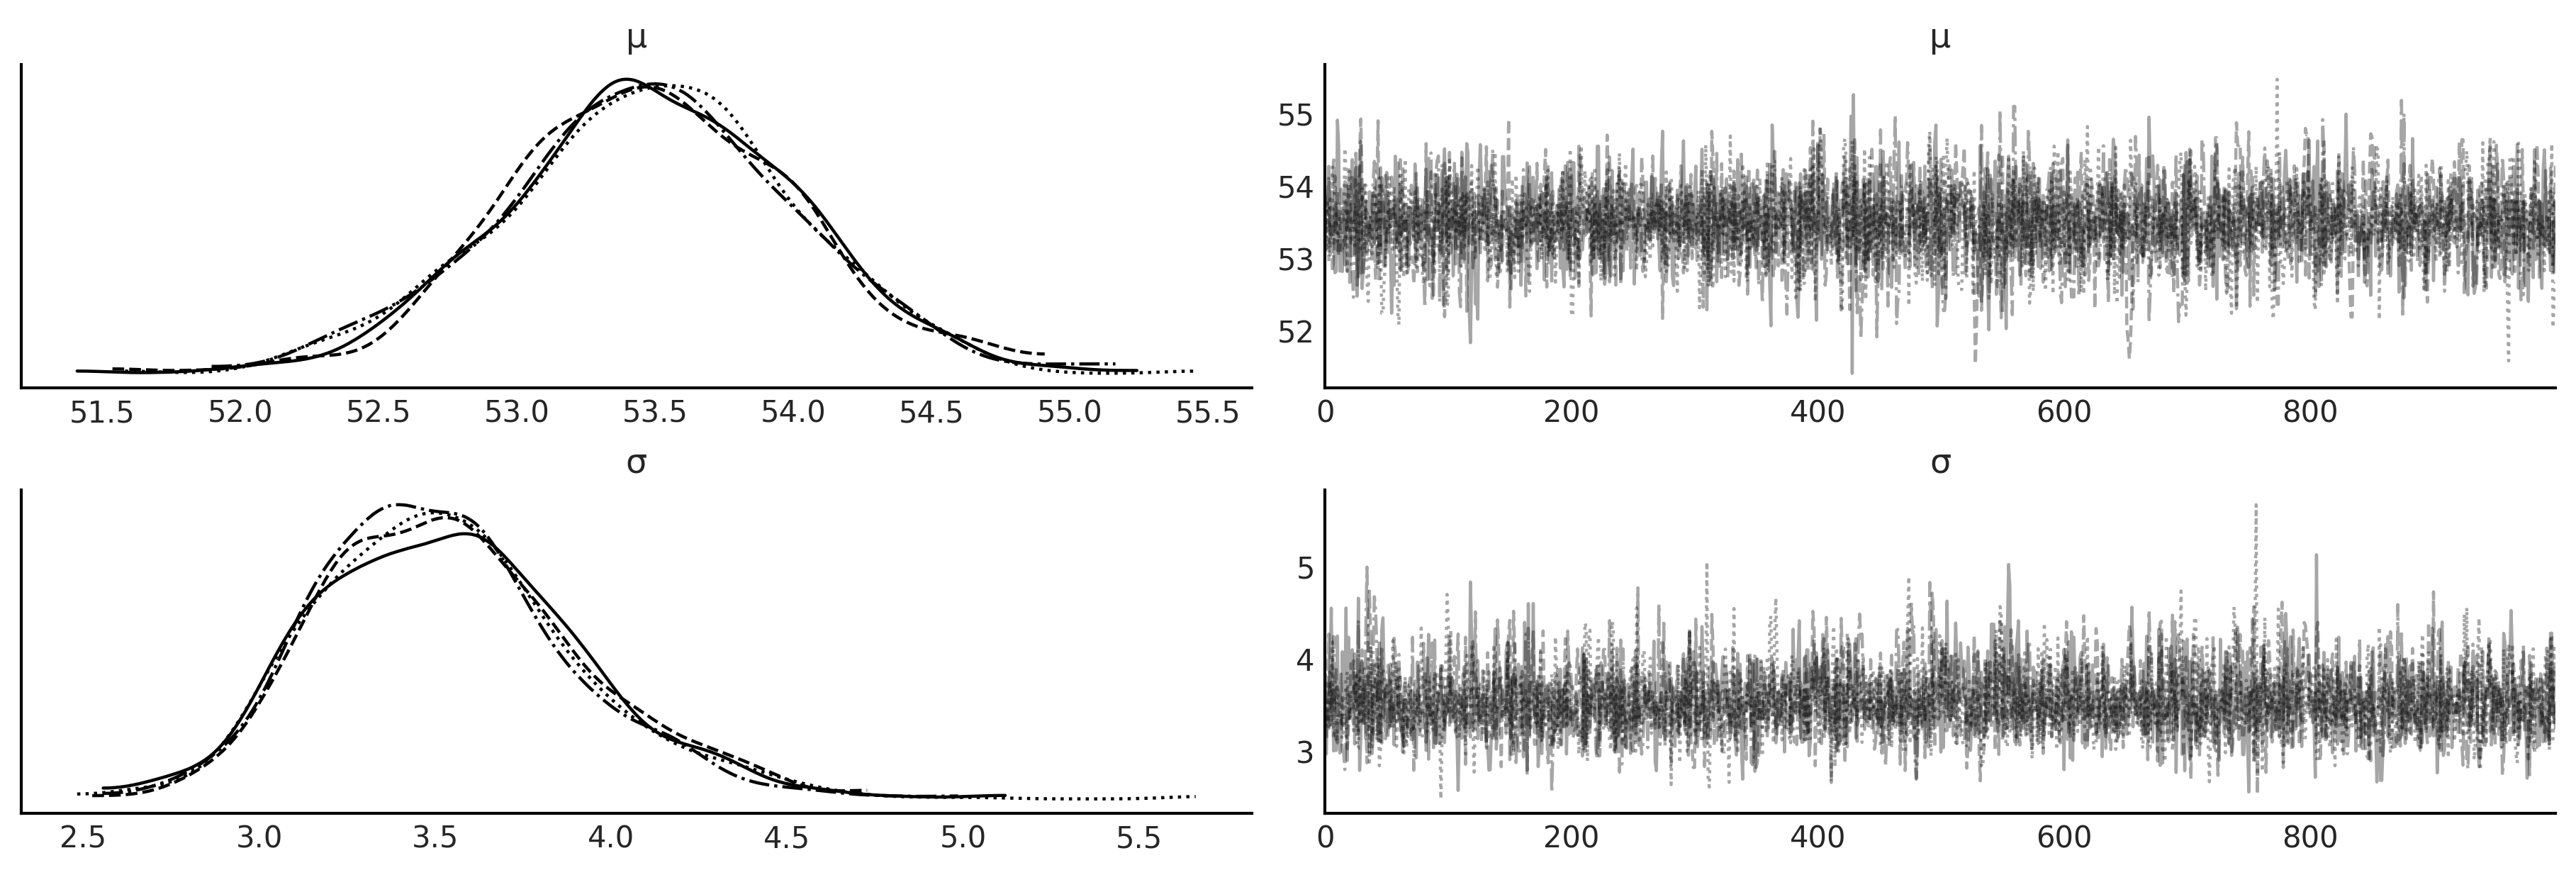

In [17]:
az.plot_trace(idata_g)
plt.savefig('fig/idata_g_trace.png')

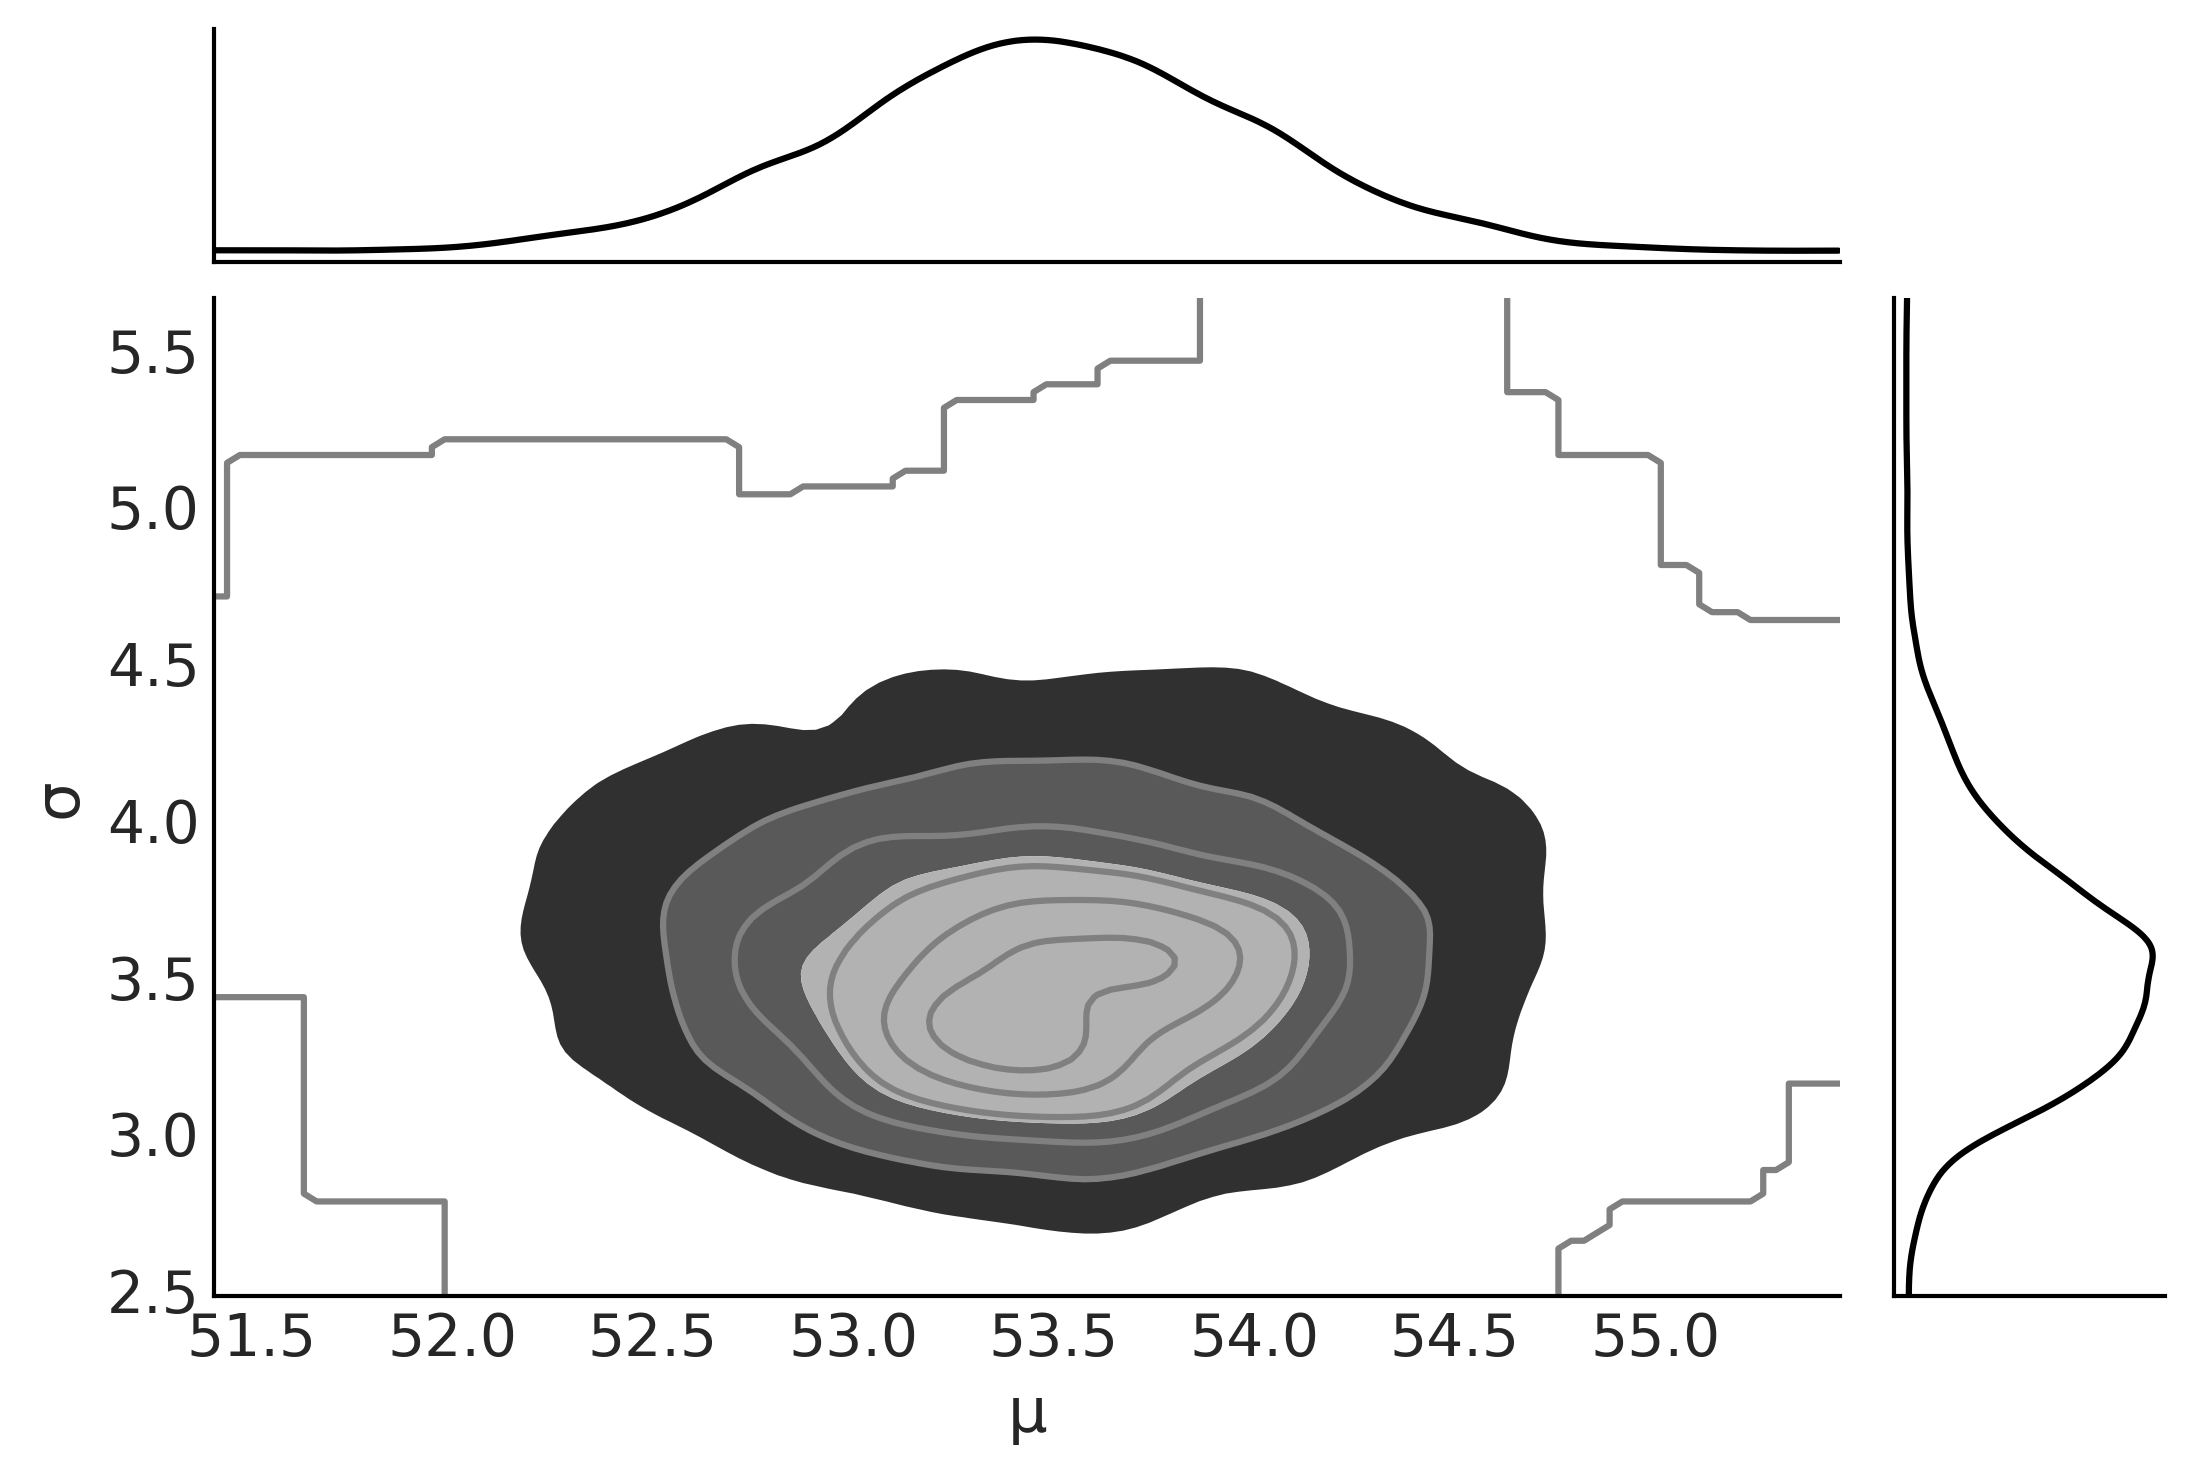

In [18]:
az.plot_pair(idata_g, kind='kde', marginals=True)
plt.savefig('fig/idata_g_pair.png')

In [19]:
az.summary(idata_g, kind='stats').round(2)

,mean,sd,hdi_3%,hdi_97%
µ,53.48,0.52,52.58,54.56
σ,3.53,0.36,2.94,4.30


In [20]:
pm.sample_posterior_predictive(idata_g, model=model_g, extend_inferencedata=True, random_seed=4591)

Sampling: [𝛄]


Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

C:\Users\David\AppData\Local\Temp\ipykernel_18428\2852411277.py:2: UserWarning: Glyph 120516 (\N{MATHEMATICAL BOLD SMALL GAMMA}) missing from font(s) DejaVu Sans.
  plt.savefig('fig/idata_g_ppc.png')
C:\Users\David\PycharmProjects\BAP3\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 120516 (\N{MATHEMATICAL BOLD SMALL GAMMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


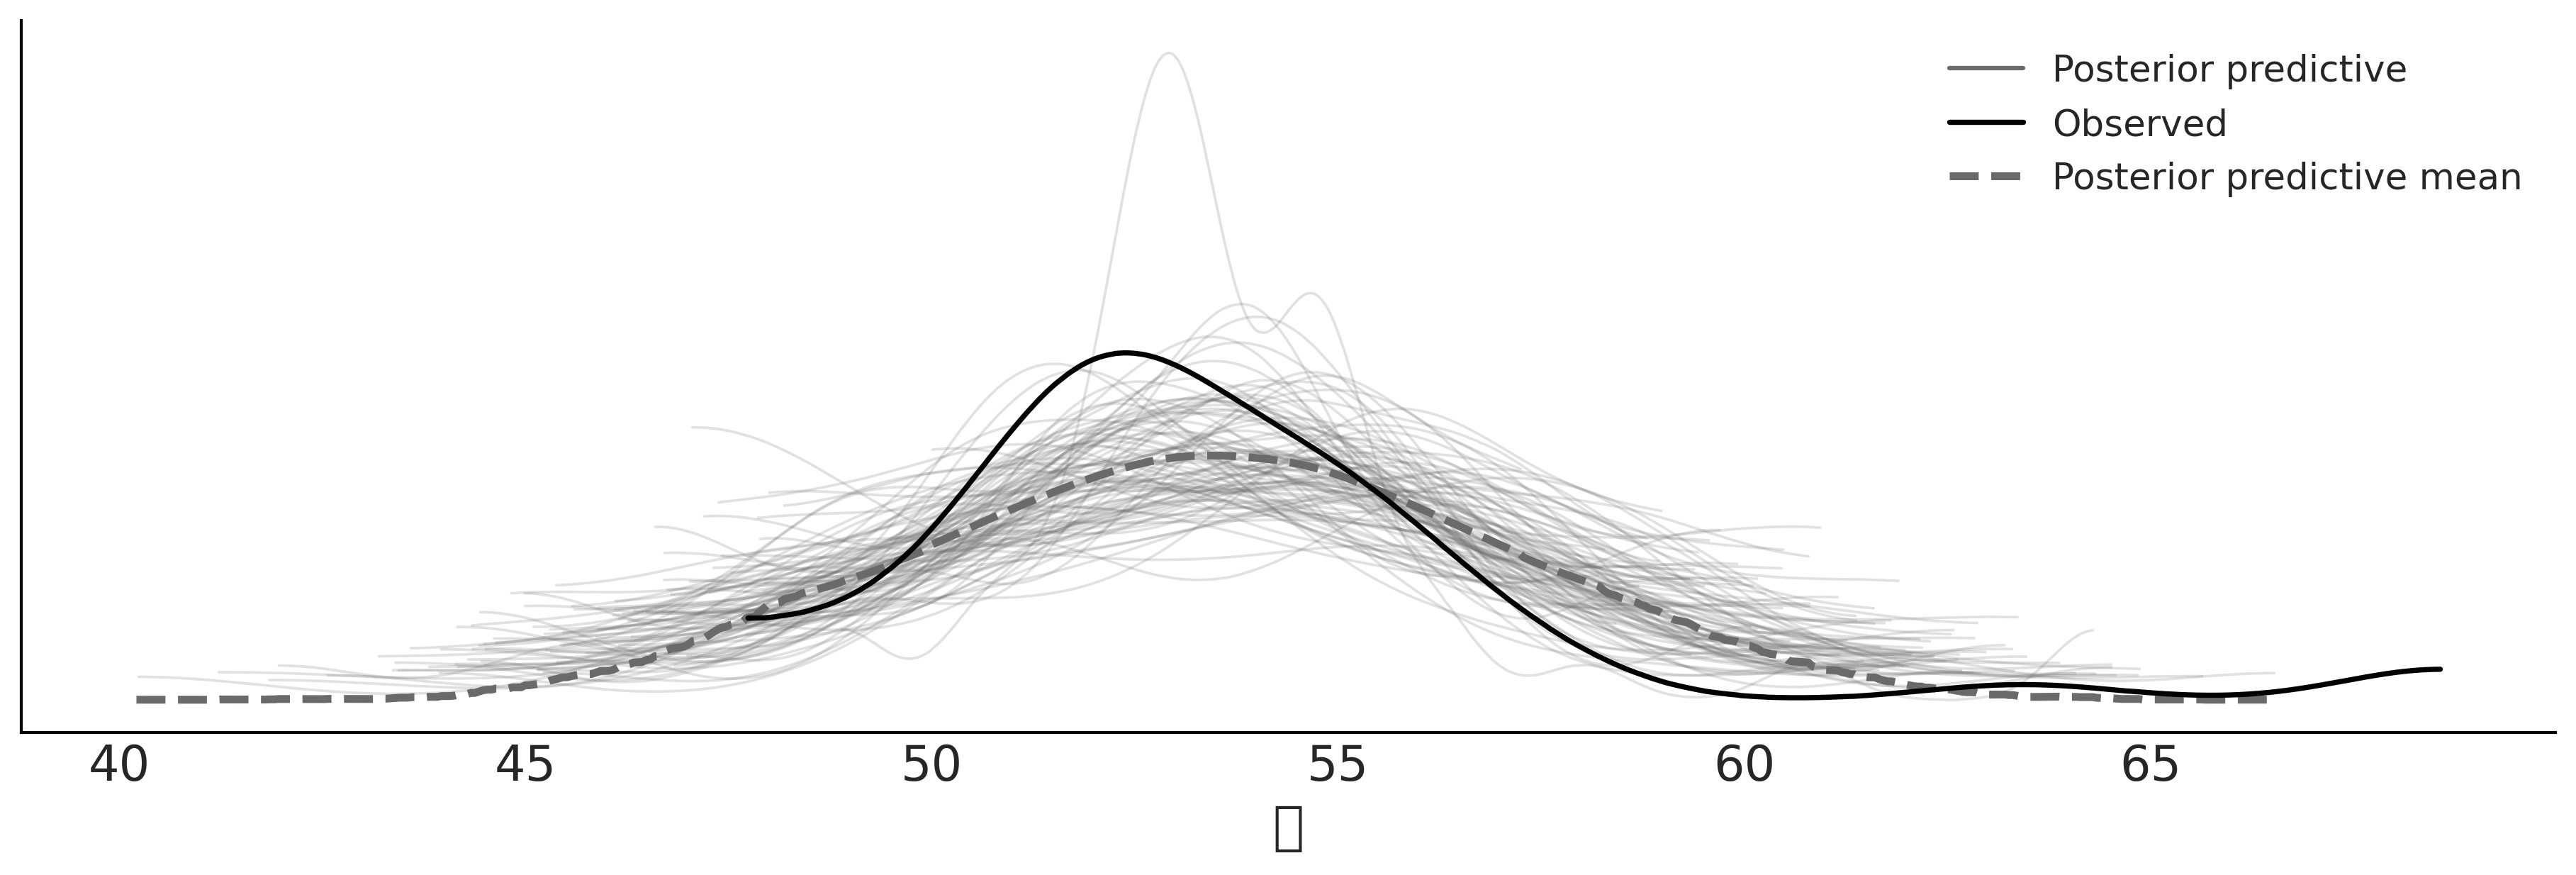

In [21]:
az.plot_ppc(idata_g, num_pp_samples=100, figsize=(12, 4), colors=['C1', 'C0', 'C1'])
plt.savefig('fig/idata_g_ppc.png')

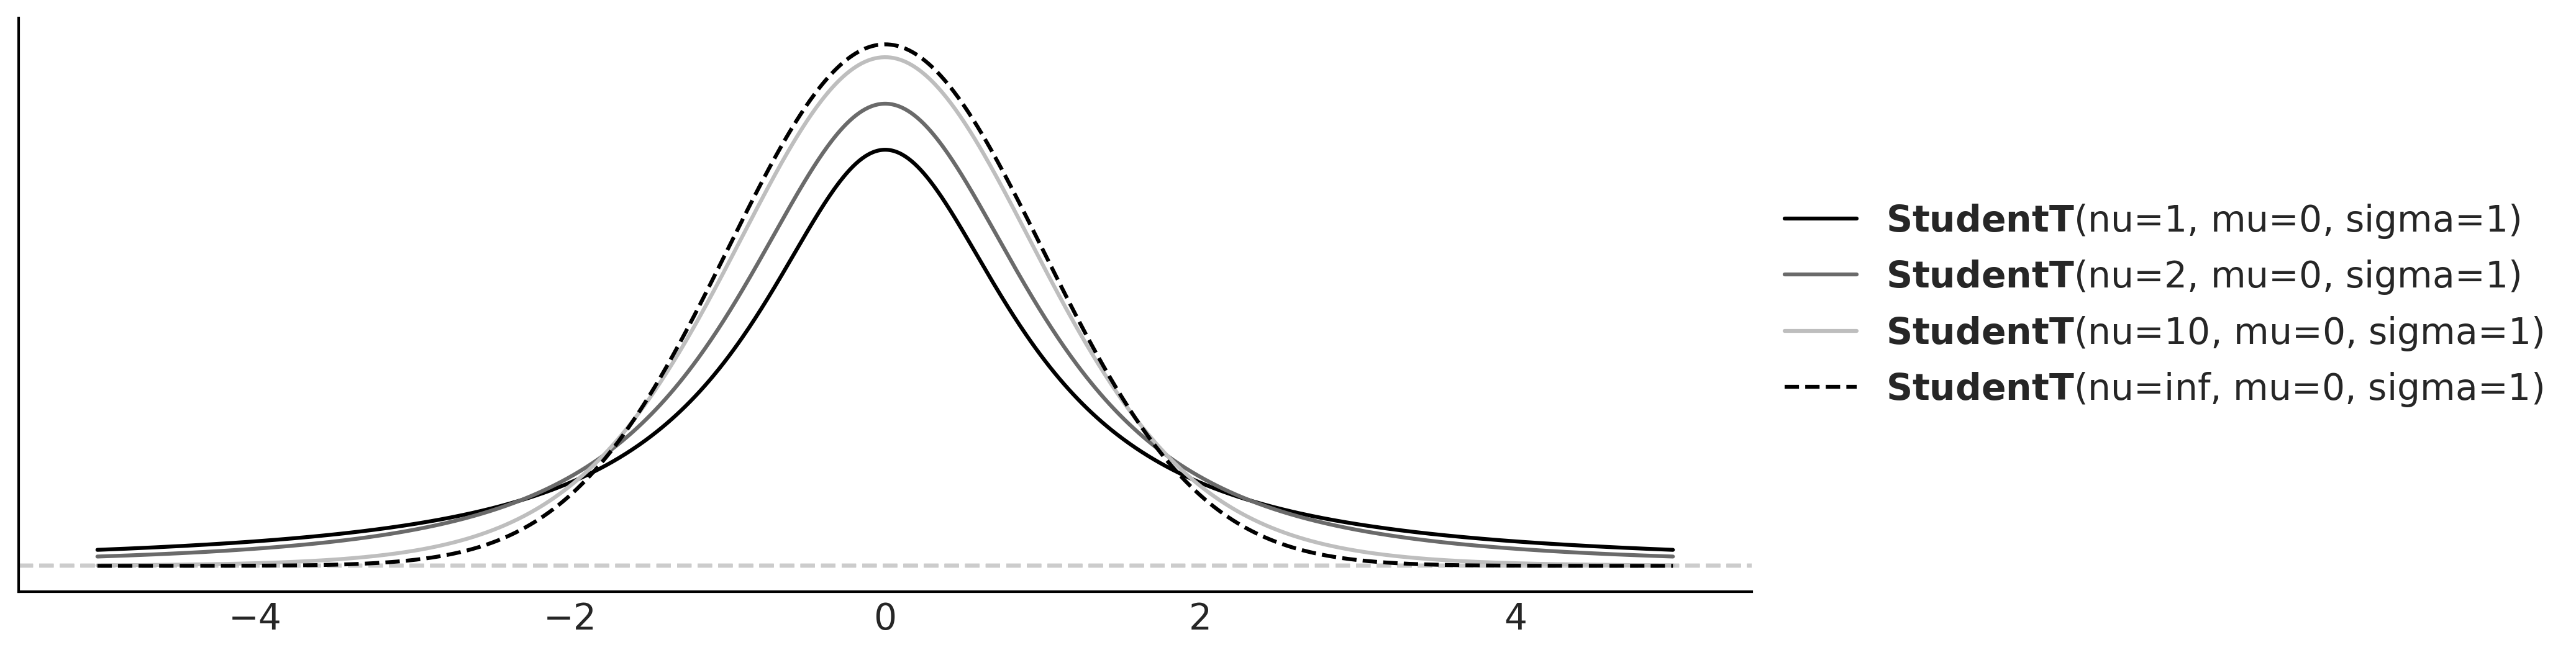

In [22]:
for nu in [1, 2, 10]:
    pz.StudentT(nu, 0, 1).plot_pdf(support=(-5, 5), figsize=(12, 4))

ax = pz.StudentT(np.inf, 0, 1).plot_pdf(support=(-5, 5), figsize=(12, 4), color='k')
ax.get_lines()[-1].set_linestyle('--')
pz.internal.plot_helper.side_legend(ax)
plt.savefig('fig/student_t.png')

In [23]:
with pm.Model() as model_t:
    μ = pm.Uniform('μ', 40, 75)
    σ = pm.HalfNormal('σ', sigma=10)
    v = pm.Exponential('v', 1/30)
    y = pm.StudentT('y', nu=v, mu=μ, sigma=σ, observed=data)
    idata_t = pm.sample(random_seed=4591)

Initializing NUTS using jitter+adapt_diag...
C:\Users\David\PycharmProjects\BAP3\.venv\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1024: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, σ, v]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 28 seconds.


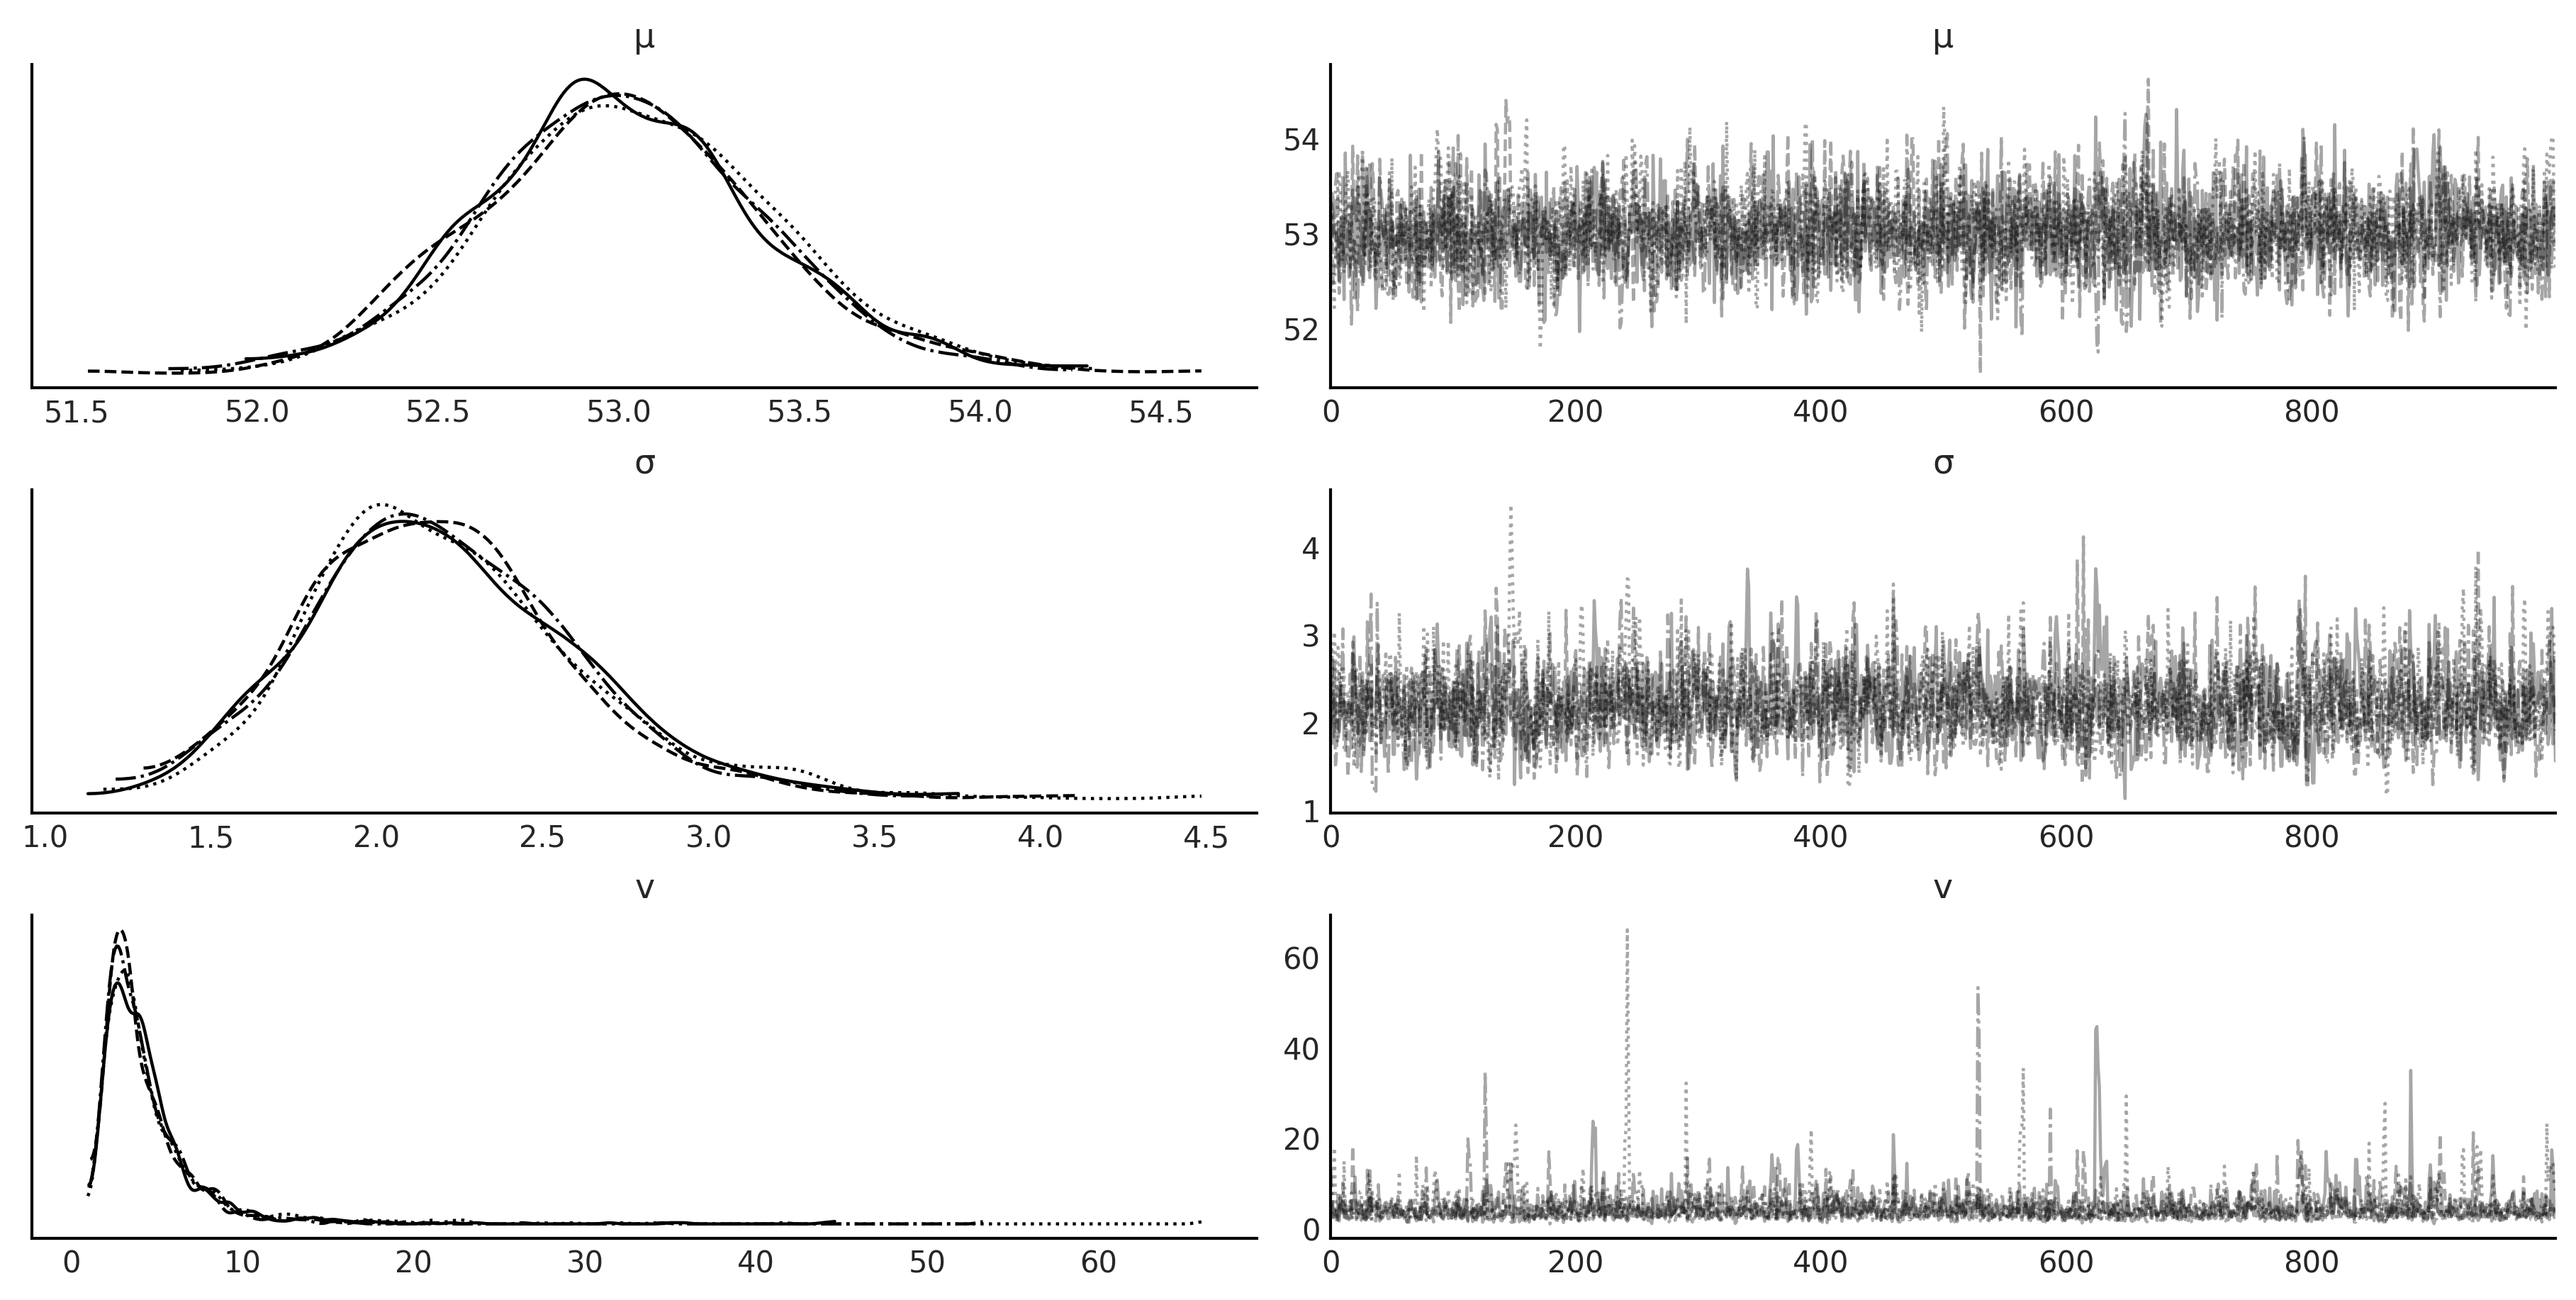

In [24]:
az.plot_trace(idata_t)
plt.savefig('fig/idata_t_trace.png')

In [25]:
az.summary(idata_t, kind='stats').round(2)

,mean,sd,hdi_3%,hdi_97%
μ,53.02,0.39,52.27,53.74
σ,2.20,0.40,1.46,2.94
v,4.53,3.49,1.24,9.15


Sampling: [y]


Output()

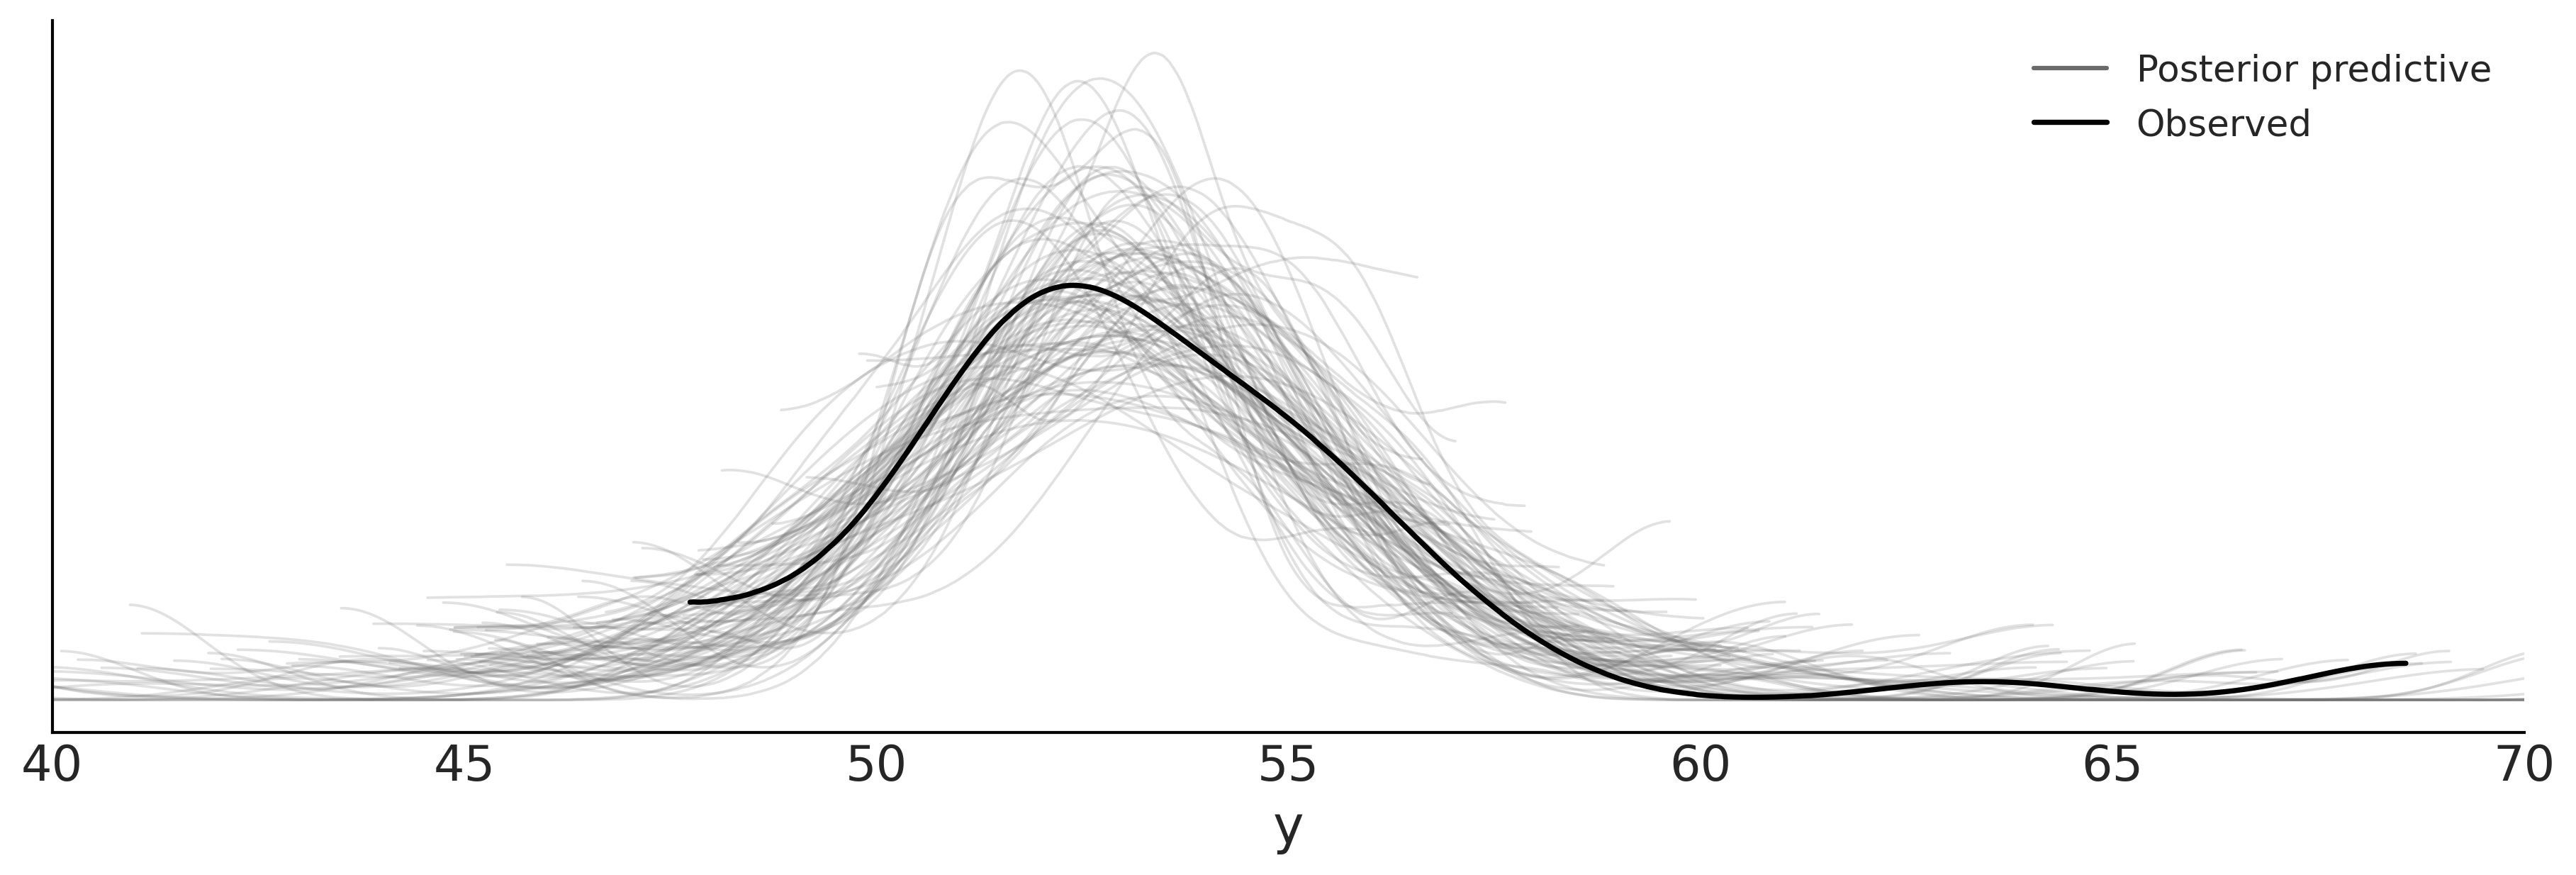

In [26]:
pm.sample_posterior_predictive(idata_t, model=model_t, extend_inferencedata=True, random_seed=123)
ax = az.plot_ppc(idata_t, num_pp_samples=100, figsize=(12, 4), mean=False, colors=['C1', 'C0', 'C1'])
ax.set_xlim(40, 70)
plt.savefig('fig/idata_t_ppc.png')

In [27]:
idata_g

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

In [28]:
posterior = idata_g.posterior

In [29]:
posterior.sel(draw=0, chain=[0, 2])

<xarray.Dataset> Size: 44B
Dimensions:  (chain: 2)
Coordinates:
  * chain    (chain) int32 8B 0 2
    draw     int32 4B 0
Data variables:
    µ        (chain) float64 16B 53.48 53.1
    σ        (chain) float64 16B 3.05 4.017
Attributes:
    created_at:                 2025-03-06T10:55:56.090772+00:00
    arviz_version:              0.20.0
    inference_library:          pymc
    inference_library_version:  5.19.1
    sampling_time:              11.46803092956543
    tuning_steps:               1000

In [30]:
posterior.mean()

<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    µ        float64 8B 53.48
    σ        float64 8B 3.534

In [31]:
posterior.mean('draw')

<xarray.Dataset> Size: 80B
Dimensions:  (chain: 4)
Coordinates:
  * chain    (chain) int32 16B 0 1 2 3
Data variables:
    µ        (chain) float64 32B 53.5 53.48 53.49 53.47
    σ        (chain) float64 32B 3.539 3.532 3.55 3.516

In [32]:
stacked = az.extract(idata_g)